# Task 3: Network Visualization

Visualize the co-expression network with modules highlighted.

**Deliverable**: `task3_network.png`

## 1. Setup & Load Data

In [1]:
import logging
from pathlib import Path
from typing import Dict, List
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")


def locate_repo_root() -> Path:
    here = Path().resolve()
    for base in [here, *here.parents]:
        if (base / "data").exists():
            return base
    raise FileNotFoundError("Could not locate repo root")


REPO_ROOT = locate_repo_root()
ARTIFACTS = REPO_ROOT / "labs/07_network_viz/assignments/artifacts"
TARGET_GENE = "TP53"
print(f"matplotlib {plt.matplotlib.__version__}")

matplotlib 3.9.4


In [2]:
# Load network from Task 2
gml_path = ARTIFACTS / "task2_network.gml"
assert gml_path.exists(), f"Network not found: {gml_path}. Run Task 2 first."
G = nx.read_gml(str(gml_path))
logging.info(
    "Loaded network: %d nodes, %d edges", G.number_of_nodes(), G.number_of_edges()
)

# Load modules
modules_df = pd.read_csv(ARTIFACTS / "task2_modules.csv")
gene_modules = dict(zip(modules_df["Gene"], modules_df["Module"]))
logging.info("Loaded %d gene-module assignments", len(gene_modules))

# Load hub genes
hub_genes_df = pd.read_csv(ARTIFACTS / "task2_hub_genes.csv")
hub_genes = set(hub_genes_df["Gene"])
logging.info("Loaded %d hub genes", len(hub_genes))

[INFO] Loaded network: 1948 nodes, 148240 edges
[INFO] Loaded 1948 gene-module assignments
[INFO] Loaded 44 hub genes


## 2. Network Statistics

In [3]:
print("=" * 60)
print("NETWORK STATISTICS")
print("=" * 60)
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Modules: {len(set(gene_modules.values()))}")
if TARGET_GENE in G.nodes():
    print(
        f"\n*** TP53: degree={G.degree(TARGET_GENE)}, module={gene_modules.get(TARGET_GENE)} ***"
    )

NETWORK STATISTICS
Nodes: 1948
Edges: 148240
Density: 0.0782
Modules: 11

*** TP53: degree=20, module=4 ***


## 3. Visualization Functions

In [4]:
def get_module_colors(n_modules: int) -> List[str]:
    cmap = (
        plt.cm.tab10
        if n_modules <= 10
        else (plt.cm.tab20 if n_modules <= 20 else plt.cm.nipy_spectral)
    )
    return [mcolors.rgb2hex(cmap(i / n_modules)) for i in range(n_modules)]


def create_node_properties(G, gene_modules, hub_genes, target_gene):
    nodes = list(G.nodes())
    n_modules = len(set(gene_modules.values()))
    module_colors = get_module_colors(n_modules)
    node_colors = [
        module_colors[gene_modules.get(n, 0) % len(module_colors)] for n in nodes
    ]
    node_sizes = [
        500 if n == target_gene else (200 if n in hub_genes else 30) for n in nodes
    ]
    labels = {n: n for n in nodes if n == target_gene or n in hub_genes}
    return {
        "colors": node_colors,
        "sizes": node_sizes,
        "labels": labels,
        "module_colors": module_colors,
    }

## 4. Create Main Visualization

Computing layout...


[INFO] [OK] Figure saved: /home/rbals/git/daha-bdhb/BDHB-lab/labs/07_network_viz/assignments/artifacts/task3_network.png


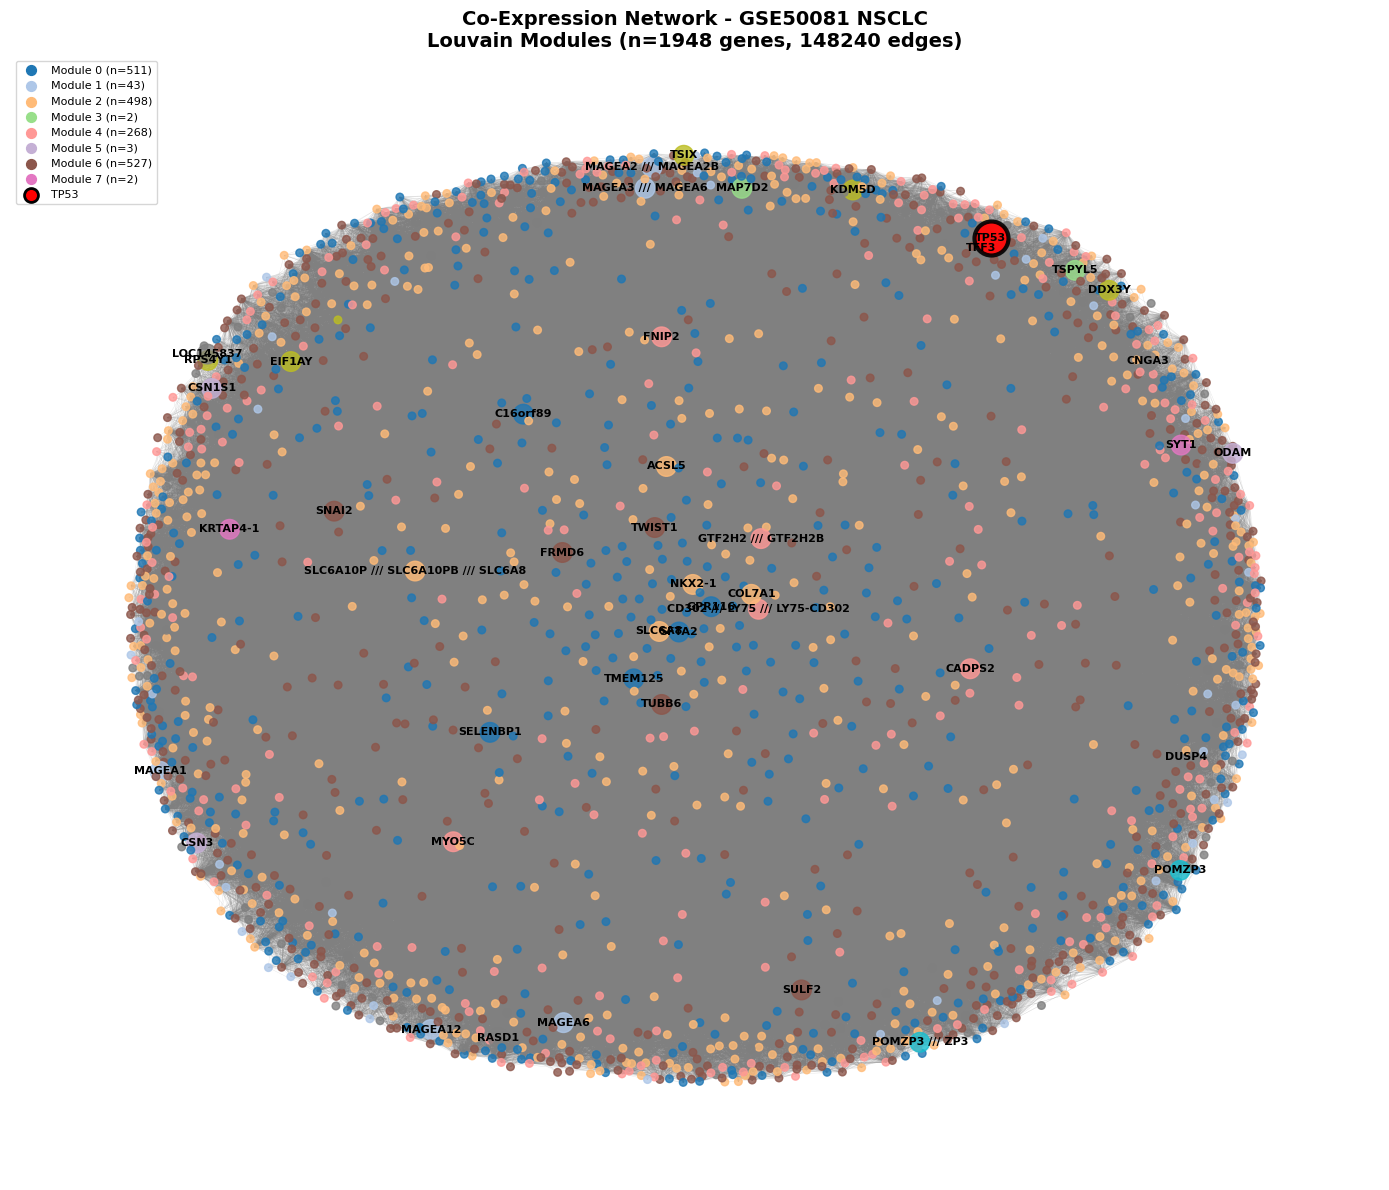

In [5]:
props = create_node_properties(G, gene_modules, hub_genes, TARGET_GENE)
fig, ax = plt.subplots(figsize=(14, 12))
print("Computing layout...")
pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.3, edge_color="gray")
nx.draw_networkx_nodes(
    G, pos, ax=ax, node_color=props["colors"], node_size=props["sizes"], alpha=0.8
)

if TARGET_GENE in G.nodes():
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=[TARGET_GENE],
        node_color="red",
        node_size=600,
        alpha=0.9,
        linewidths=3,
        edgecolors="black",
    )

nx.draw_networkx_labels(
    G, pos, ax=ax, labels=props["labels"], font_size=8, font_weight="bold"
)

# Legend
n_modules = len(set(gene_modules.values()))
for i in range(min(n_modules, 8)):
    size = sum(1 for v in gene_modules.values() if v == i)
    ax.scatter(
        [], [], c=props["module_colors"][i], s=50, label=f"Module {i} (n={size})"
    )
ax.scatter(
    [], [], c="red", s=100, edgecolors="black", linewidths=2, label=f"{TARGET_GENE}"
)
ax.legend(loc="upper left", fontsize=8)

ax.set_title(
    f"Co-Expression Network - GSE50081 NSCLC\nLouvain Modules (n={G.number_of_nodes()} genes, {G.number_of_edges()} edges)",
    fontsize=14,
    fontweight="bold",
)
ax.axis("off")
plt.tight_layout()

output_path = ARTIFACTS / "task3_network.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
logging.info("[OK] Figure saved: %s", output_path)
plt.show()

## 5. Additional Plots

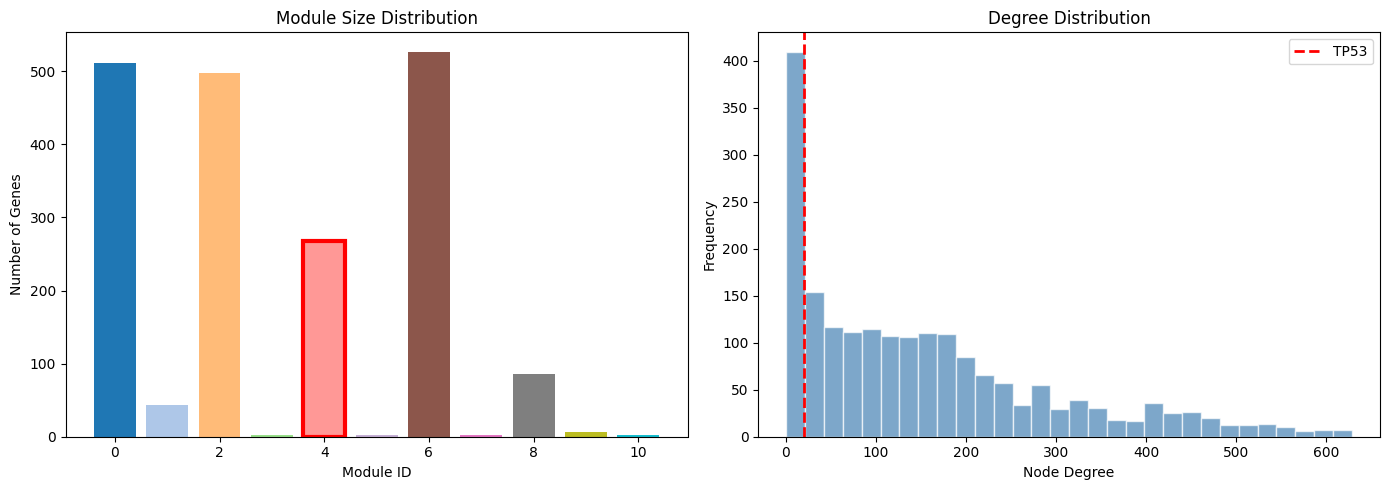

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Module sizes
module_sizes = pd.Series(gene_modules).value_counts().sort_index()
colors = get_module_colors(len(module_sizes))
bars = axes[0].bar(module_sizes.index, module_sizes.values, color=colors)
axes[0].set_xlabel("Module ID")
axes[0].set_ylabel("Number of Genes")
axes[0].set_title("Module Size Distribution")
if TARGET_GENE in gene_modules:
    tp53_mod = gene_modules[TARGET_GENE]
    bars[tp53_mod].set_edgecolor("red")
    bars[tp53_mod].set_linewidth(3)

# Degree distribution
degrees = [d for n, d in G.degree()]
axes[1].hist(degrees, bins=30, color="steelblue", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Node Degree")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Degree Distribution")
if TARGET_GENE in G.nodes():
    axes[1].axvline(
        G.degree(TARGET_GENE),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"{TARGET_GENE}",
    )
    axes[1].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS / "task3_statistics.png", dpi=200, bbox_inches="tight")
plt.show()

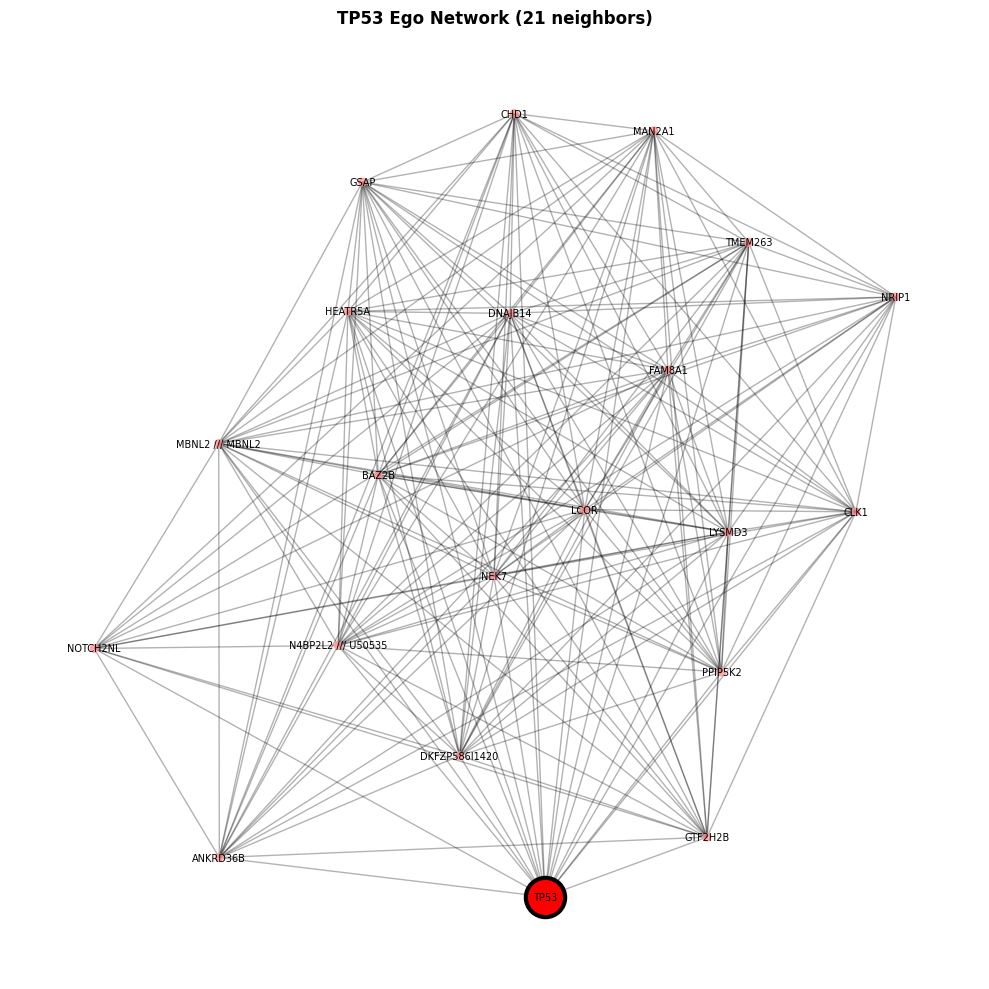

In [7]:
# TP53 ego network
if TARGET_GENE in G.nodes():
    fig, ax = plt.subplots(figsize=(10, 10))
    ego = nx.ego_graph(G, TARGET_GENE, radius=1)
    ego_props = create_node_properties(ego, gene_modules, hub_genes, TARGET_GENE)
    pos = nx.spring_layout(ego, k=2, seed=42)
    nx.draw_networkx_edges(ego, pos, ax=ax, alpha=0.3, width=1)
    nx.draw_networkx_nodes(
        ego,
        pos,
        ax=ax,
        node_color=ego_props["colors"],
        node_size=ego_props["sizes"],
        alpha=0.8,
    )
    nx.draw_networkx_nodes(
        ego,
        pos,
        ax=ax,
        nodelist=[TARGET_GENE],
        node_color="red",
        node_size=800,
        edgecolors="black",
        linewidths=3,
    )
    nx.draw_networkx_labels(ego, pos, ax=ax, font_size=7)
    ax.set_title(
        f"{TARGET_GENE} Ego Network ({ego.number_of_nodes()} neighbors)",
        fontsize=12,
        fontweight="bold",
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "task3_ego_network.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print(f"{TARGET_GENE} not in network")

## 6. Summary

In [8]:
print(f"\n{'=' * 60}")
print("TASK 3 COMPLETE - Network Visualization")
print(f"{'=' * 60}")
print(f"Outputs:")
print(f"  - task3_network.png (main deliverable)")
print(f"  - task3_statistics.png")
if TARGET_GENE in G.nodes():
    print(f"  - task3_ego_network.png")
print(
    f"\nNetwork: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, {len(set(gene_modules.values()))} modules"
)


TASK 3 COMPLETE - Network Visualization
Outputs:
  - task3_network.png (main deliverable)
  - task3_statistics.png
  - task3_ego_network.png

Network: 1948 nodes, 148240 edges, 11 modules
